Device: cuda
Loading tokenizer...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...


Evaluating LASS PPL...
  Sparsity : 21.96%
  PPL      : 19.67


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved to : /kaggle/working/pruned_lass

Evaluating original model PPL...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  PPL (original): 18.10


       ABLATION STUDY: SparseGPT vs LASS
Model                            Sparsity      PPL      Δ PPL
--------------------------------------------------------------
Original (dense)                    0.00%    18.10          —
Uniform SparseGPT                  21.73%    19.77      +9.3%
SparseGPT + LASS (ours)            21.96%    19.67      +8.7%

LASS improvement over uniform: 0.10 PPL points
(Lower is better — LASS should win here)


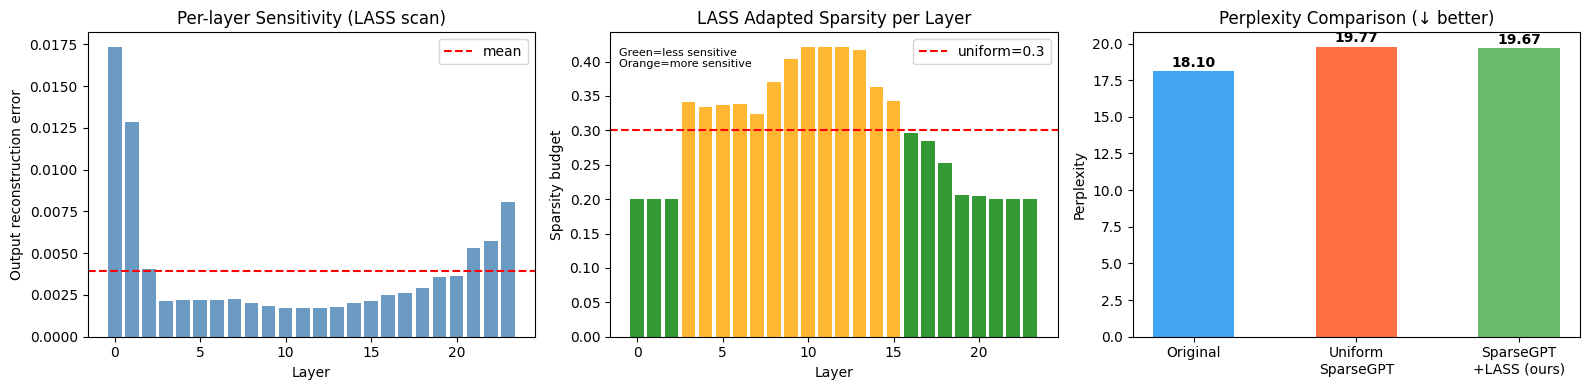


Plot saved: /kaggle/working/lass_ablation.png
Summary saved: /kaggle/working/ablation_summary.json
Zips ready in Kaggle Output panel.

>>> Next step: use OUTPUT_LASS as input to your KD notebook
    Path: /kaggle/working/pruned_lass

DONE ✓


In [1]:


import os, gc, json, math, copy, shutil
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


@dataclass
class PruneConfig:
    model_name: str               = "Qwen/Qwen2.5-0.5B-Instruct"
    sparsity_ratio: float         = 0.30
    lass_min_sparsity: float      = 0.20
    lass_max_sparsity: float      = 0.45
    lass_sensitivity_samples: int = 16
    n_calibration_samples: int    = 128
    calibration_seqlen: int       = 512
    blocksize: int                = 128
    percdamp: float               = 0.01

cfg = PruneConfig()

OUTPUT_UNIFORM = "/kaggle/working/pruned_uniform"
OUTPUT_LASS    = "/kaggle/working/pruned_lass"
os.makedirs(OUTPUT_UNIFORM, exist_ok=True)
os.makedirs(OUTPUT_LASS,    exist_ok=True)



def load_model():
    tok = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        cfg.model_name,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )
    mdl.eval()
    for p in mdl.parameters():
        p.requires_grad = False
    return mdl, tok

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token



def get_calibration_data(nsamples, seqlen, tokenizer, seed=0):
    ds = load_dataset(
        "allenai/c4",
        data_files={"train": "en/c4-train.00000-of-01024.json.gz"},
        split="train",
    )
    rng = np.random.default_rng(seed)
    samples, attempts = [], 0
    pbar = tqdm(total=nsamples, desc="Calibration samples")
    while len(samples) < nsamples and attempts < nsamples * 300:
        idx = int(rng.integers(0, len(ds)))
        enc = tokenizer(ds[idx]["text"], return_tensors="pt", add_special_tokens=False)
        if enc.input_ids.shape[1] >= seqlen:
            start = int(rng.integers(0, enc.input_ids.shape[1] - seqlen + 1))
            samples.append(enc.input_ids[:, start:start + seqlen])
            pbar.update(1)
        attempts += 1
    pbar.close()
    return samples

print(f"Collecting {cfg.n_calibration_samples} calibration samples...")
calib_samples = get_calibration_data(cfg.n_calibration_samples, cfg.calibration_seqlen, tokenizer)
print(f"Got {len(calib_samples)} samples ✓")


class SparseGPT:
    def __init__(self, layer: nn.Linear):
        self.layer   = layer
        self.rows    = layer.weight.shape[0]
        self.columns = layer.weight.shape[1]
        self.dev     = layer.weight.device
        self.H       = torch.zeros((self.columns, self.columns),
                                   device=self.dev, dtype=torch.float32)
        self.nsamples = 0

    def add_batch(self, inp: torch.Tensor):
        if inp.dim() > 2:
            inp = inp.reshape(-1, inp.shape[-1])
        inp = inp.to(self.dev, dtype=torch.float32)
        bs  = inp.shape[0]
        self.H       *= self.nsamples / (self.nsamples + bs)
        self.nsamples += bs
        inp            = inp * math.sqrt(2.0 / self.nsamples)
        self.H        += inp.t() @ inp

    def prune(self, sparsity: float, blocksize: int = 128, percdamp: float = 0.01):
        W    = self.layer.weight.data.clone().float()
        H    = self.H.clone()
        dead = torch.diag(H) == 0
        H[dead, dead] = 1.0
        W[:, dead]    = 0.0

        damp     = percdamp * torch.mean(torch.diag(H))
        diag_idx = torch.arange(self.columns, device=self.dev)
        H[diag_idx, diag_idx] += damp

        H    = torch.linalg.cholesky(H)
        H    = torch.cholesky_inverse(H)
        H    = torch.linalg.cholesky(H, upper=True)
        Hinv = H

        mask = torch.zeros_like(W, dtype=torch.bool)

        for i1 in range(0, self.columns, blocksize):
            i2    = min(i1 + blocksize, self.columns)
            count = i2 - i1
            W1    = W[:, i1:i2].clone()
            Q1    = torch.zeros_like(W1)
            Err1  = torch.zeros_like(W1)
            mask1 = torch.zeros_like(W1, dtype=torch.bool)
            Hinv1 = Hinv[i1:i2, i1:i2]

            if sparsity > 0:
                scores = (W1 ** 2) / (torch.diag(Hinv1).reshape(1, -1) ** 2 + 1e-8)
                k      = max(1, int(scores.numel() * sparsity))
                thresh = torch.sort(scores.flatten())[0][k - 1]
                mask1  = scores <= thresh

            for j in range(count):
                w = W1[:, j]
                d = Hinv1[j, j]
                q = w.clone()
                q[mask1[:, j]] = 0
                Q1[:, j] = q
                err = (w - q) / (d + 1e-8)
                W1[:, j:] -= err.unsqueeze(1) * Hinv1[j, j:].unsqueeze(0)
                Err1[:, j] = err

            W[:, i1:i2]   = Q1
            mask[:, i1:i2] = mask1
            W[:, i2:]     -= Err1 @ Hinv[i1:i2, i2:]

        self.layer.weight.data = W.to(self.layer.weight.dtype)
        return mask

    def free(self):
        self.H = None
        if self.dev.type == "cuda":
            torch.cuda.empty_cache()


def find_linears(module):
    return {n: m for n, m in module.named_modules() if isinstance(m, nn.Linear)}


def capture_layer_inputs(model, calib_samples, n_samples=None):
    layers      = model.model.layers
    n           = n_samples or len(calib_samples)
    dtype       = next(iter(model.parameters())).dtype
    hidden_size = model.config.hidden_size
    seqlen      = calib_samples[0].shape[1]

    inps  = torch.zeros((n, seqlen, hidden_size), dtype=dtype, device=DEVICE)
    cache = {"i": 0, "kw": {}}

    class Catcher(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.module = m
        def forward(self, h, **kw):
            inps[cache["i"]] = h
            cache["i"]      += 1
            cache["kw"]      = kw
            raise ValueError
        def __getattr__(self, name):
            try:
                return super().__getattr__(name)
            except AttributeError:
                return getattr(self.module, name)

    model.model.embed_tokens.to(DEVICE)
    if hasattr(model.model, "rotary_emb") and model.model.rotary_emb is not None:
        model.model.rotary_emb.to(DEVICE)

    layers[0] = Catcher(layers[0])
    for s in calib_samples[:n]:
        try:
            model(s.to(DEVICE))
        except ValueError:
            pass
    layers[0] = layers[0].module

    model.model.embed_tokens.cpu()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return inps, cache["kw"]


# Fix: out_orig captured before any pruning; pruned weights copied into
# the real layer BEFORE measuring out_pruned; original weights restored after.
def compute_lass_budgets(model, calib_samples, cfg):
    print("\n[LASS] Running sensitivity pre-scan (fixed)...")
    layers  = model.model.layers
    n_scan  = min(cfg.lass_sensitivity_samples, len(calib_samples))
    inps, kw = capture_layer_inputs(model, calib_samples, n_scan)
    outs     = torch.zeros_like(inps)

    sensitivities = []

    for idx in tqdm(range(len(layers)), desc="LASS sensitivity scan"):
        layer  = layers[idx].to(DEVICE)
        subset = find_linears(layer)

        # collect activations via hooks
        gpts    = {n: SparseGPT(lin) for n, lin in subset.items()}
        handles = []
        def make_hook(name):
            def h(_, inp, __): gpts[name].add_batch(inp[0].data)
            return h
        for n, lin in subset.items():
            handles.append(lin.register_forward_hook(make_hook(n)))
        with torch.no_grad():
            for j in range(n_scan):
                layer(inps[j].unsqueeze(0), **kw)
        for h in handles:
            h.remove()

        # ---- FIXED sensitivity measurement ----
        sample_in = inps[0].unsqueeze(0).to(DEVICE)

        # 1. original output BEFORE any pruning
        with torch.no_grad():
            out_orig = layer(sample_in, **kw)[0].clone()

        errors = []
        for n, gpt in gpts.items():
            W_orig = gpt.layer.weight.data.clone()

            # 2. prune a deep copy, then copy pruned weights into real layer
            gpt_copy = copy.deepcopy(gpt)
            gpt_copy.prune(cfg.sparsity_ratio,
                           blocksize=cfg.blocksize,
                           percdamp=cfg.percdamp)
            gpt.layer.weight.data.copy_(gpt_copy.layer.weight.data)

            # 3. measure output WITH pruned weights
            with torch.no_grad():
                out_pruned = layer(sample_in, **kw)[0].clone()

            # 4. relative output error
            err = (out_orig - out_pruned).norm().item() / \
                  (out_orig.norm().item() + 1e-9)
            errors.append(err)

            # 5. restore original weights
            gpt.layer.weight.data.copy_(W_orig)
            gpt.free()
            del gpt_copy

        sensitivities.append(float(np.mean(errors)))

        # propagate for next layer (original weights restored)
        with torch.no_grad():
            for j in range(n_scan):
                outs[j] = layer(inps[j].unsqueeze(0), **kw)[0].squeeze(0)

        layers[idx] = layer.cpu()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        inps, outs = outs, inps

 
    sens_arr = np.array(sensitivities)
    print(f"\n[LASS] Raw sensitivities: min={sens_arr.min():.4f} "
          f"max={sens_arr.max():.4f} mean={sens_arr.mean():.4f}")

    # fallback to uniform if all sensitivities are zero
    if sens_arr.max() < 1e-8:
        print("[LASS] WARNING: all sensitivities zero — using uniform fallback")
        n = len(layers)
        return ({i: cfg.sparsity_ratio for i in range(n)},
                sensitivities,
                [cfg.sparsity_ratio] * n)

    inv_sens = 1.0 / (sens_arr + 1e-6)
    inv_norm = inv_sens / inv_sens.mean()

    param_counts = np.array([
        sum(p.numel() for p in layers[i].parameters())
        for i in range(len(layers))
    ])

    raw     = cfg.sparsity_ratio * inv_norm
    raw     = np.clip(raw, cfg.lass_min_sparsity, cfg.lass_max_sparsity)
    w_mean  = np.sum(raw * param_counts) / np.sum(param_counts)
    scale   = cfg.sparsity_ratio / w_mean
    adapted = np.clip(raw * scale, cfg.lass_min_sparsity, cfg.lass_max_sparsity)

    budgets = {i: float(adapted[i]) for i in range(len(layers))}

    print(f"[LASS] Adapted range : [{adapted.min():.3f}, {adapted.max():.3f}]")
    print(f"[LASS] Weighted mean : "
          f"{np.sum(adapted * param_counts) / np.sum(param_counts):.4f} "
          f"(target={cfg.sparsity_ratio})")

    return budgets, sensitivities, adapted.tolist()



def prune_model(model, calib_samples, cfg, layer_budgets, label=""):
    layers = model.model.layers
    model.config.use_cache = False

    print(f"\nCapturing layer inputs for [{label}]...")
    inps, kw = capture_layer_inputs(model, calib_samples)
    outs      = torch.zeros_like(inps)

    all_masks, per_layer_stats = {}, []

    for idx in tqdm(range(len(layers)), desc=f"Pruning [{label}]"):
        layer  = layers[idx].to(DEVICE)
        subset = find_linears(layer)
        gpts   = {n: SparseGPT(lin) for n, lin in subset.items()}

        handles = []
        def make_hook(name):
            def h(_, inp, __): gpts[name].add_batch(inp[0].data)
            return h
        for n, lin in subset.items():
            handles.append(lin.register_forward_hook(make_hook(n)))
        for j in range(len(calib_samples)):
            layer(inps[j].unsqueeze(0), **kw)
        for h in handles:
            h.remove()

        budget = layer_budgets[idx]
        stats  = {"layer": idx, "budget": budget, "sublayers": {}}

        for n, gpt in gpts.items():
            mask   = gpt.prune(budget, blocksize=cfg.blocksize,
                               percdamp=cfg.percdamp)
            actual = mask.float().mean().item()
            stats["sublayers"][n] = actual
            all_masks[f"layer.{idx}.{n}"] = mask.cpu()
            gpt.free()

        with torch.no_grad():
            for j in range(len(calib_samples)):
                outs[j] = layer(inps[j].unsqueeze(0), **kw)[0].squeeze(0)

        layers[idx] = layer.cpu()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        inps, outs = outs, inps
        per_layer_stats.append(stats)

    model.config.use_cache = True
    return all_masks, per_layer_stats



def evaluate_ppl(model, tokenizer, seqlen=512, n_chunks=40):
    model = model.to(DEVICE)
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    enc  = tokenizer("\n\n".join(data["text"]), return_tensors="pt").input_ids

    nlls = []
    with torch.no_grad():
        for i in range(min(n_chunks, enc.shape[1] // seqlen)):
            batch = enc[:, i * seqlen:(i + 1) * seqlen].to(DEVICE)
            loss  = model(batch, labels=batch).loss.float()
            nlls.append(loss * (seqlen - 1))

    ppl = torch.exp(torch.stack(nlls).sum() / (len(nlls) * (seqlen - 1)))
    model.cpu()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return ppl.item()


def compute_sparsity(model):
    total, zeros = 0, 0
    for n, p in model.named_parameters():
        if "weight" in n and p.dim() >= 2:
            total += p.numel()
            zeros += (p == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0



print("\n" + "="*55)
print("  RUN 1: Uniform SparseGPT (no LASS) — baseline")
print("="*55)

model_uniform, _ = load_model()
n_layers         = len(model_uniform.model.layers)
uniform_budgets  = {i: cfg.sparsity_ratio for i in range(n_layers)}

masks_uniform, stats_uniform = prune_model(
    model_uniform, calib_samples, cfg, uniform_budgets, label="Uniform"
)

print("\nEvaluating Uniform SparseGPT PPL...")
ppl_uniform  = evaluate_ppl(model_uniform, tokenizer)
spar_uniform = compute_sparsity(model_uniform)
print(f"  Sparsity : {spar_uniform:.2f}%")
print(f"  PPL      : {ppl_uniform:.2f}")

model_uniform.save_pretrained(OUTPUT_UNIFORM)
tokenizer.save_pretrained(OUTPUT_UNIFORM)
print(f"  Saved to : {OUTPUT_UNIFORM}")

del model_uniform
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()


print("\n" + "="*55)
print("  RUN 2: SparseGPT + LASS (our novelty)")
print("="*55)

model_lass, _ = load_model()

lass_budgets, lass_sensitivities, lass_adapted = compute_lass_budgets(
    model_lass, calib_samples, cfg
)

print("\nPer-layer LASS budgets:")
for i, (s, sens) in enumerate(zip(lass_adapted, lass_sensitivities)):
    bar = "█" * int(s * 30)
    tag = "↓ protected" if s < cfg.sparsity_ratio else "↑ pruned more"
    print(f"  Layer {i:2d}: {s:.3f}  sens={sens:.4f}  {bar}  {tag}")

masks_lass, stats_lass = prune_model(
    model_lass, calib_samples, cfg, lass_budgets, label="LASS"
)

print("\nEvaluating LASS PPL...")
ppl_lass  = evaluate_ppl(model_lass, tokenizer)
spar_lass = compute_sparsity(model_lass)
print(f"  Sparsity : {spar_lass:.2f}%")
print(f"  PPL      : {ppl_lass:.2f}")

model_lass.save_pretrained(OUTPUT_LASS)
tokenizer.save_pretrained(OUTPUT_LASS)
print(f"  Saved to : {OUTPUT_LASS}")

del model_lass
gc.collect()
if DEVICE == "cuda": torch.cuda.empty_cache()



print("\nEvaluating original model PPL...")
model_orig, _ = load_model()
ppl_orig      = evaluate_ppl(model_orig, tokenizer)
print(f"  PPL (original): {ppl_orig:.2f}")
del model_orig
gc.collect()



inc_u = (ppl_uniform - ppl_orig) / ppl_orig * 100
inc_l = (ppl_lass    - ppl_orig) / ppl_orig * 100
lass_improvement = ppl_uniform - ppl_lass

print("\n\n" + "="*62)
print("       ABLATION STUDY: SparseGPT vs LASS")
print("="*62)
print(f"{'Model':<30} {'Sparsity':>10} {'PPL':>8} {'Δ PPL':>10}")
print("-"*62)
print(f"{'Original (dense)':<30} {'0.00%':>10} {ppl_orig:>8.2f} {'—':>10}")
print(f"{'Uniform SparseGPT':<30} {spar_uniform:>9.2f}% {ppl_uniform:>8.2f} {inc_u:>+9.1f}%")
print(f"{'SparseGPT + LASS (ours)':<30} {spar_lass:>9.2f}% {ppl_lass:>8.2f} {inc_l:>+9.1f}%")
print("="*62)
print(f"\nLASS improvement over uniform: {lass_improvement:.2f} PPL points")
print(f"(Lower is better — LASS should win here)")



fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n         = len(lass_sensitivities)
layer_ids = list(range(n))

axes[0].bar(layer_ids, lass_sensitivities, color="steelblue", alpha=0.8)
axes[0].axhline(np.mean(lass_sensitivities), color="red", ls="--", label="mean")
axes[0].set_title("Per-layer Sensitivity (LASS scan)")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Output reconstruction error")
axes[0].legend()

axes[1].bar(layer_ids, lass_adapted,
            color=["green" if s < cfg.sparsity_ratio else "orange"
                   for s in lass_adapted], alpha=0.8)
axes[1].axhline(cfg.sparsity_ratio, color="red", ls="--",
                label=f"uniform={cfg.sparsity_ratio}")
axes[1].set_title("LASS Adapted Sparsity per Layer")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Sparsity budget")
axes[1].legend()
axes[1].text(0.02, 0.95, "Green=less sensitive\nOrange=more sensitive",
             transform=axes[1].transAxes, fontsize=8, va="top")

models_ = ["Original", "Uniform\nSparseGPT", "SparseGPT\n+LASS (ours)"]
ppls_   = [ppl_orig, ppl_uniform, ppl_lass]
colors_ = ["#2196F3", "#FF5722", "#4CAF50"]
bars    = axes[2].bar(models_, ppls_, color=colors_, alpha=0.85, width=0.5)
axes[2].set_title("Perplexity Comparison (↓ better)")
axes[2].set_ylabel("Perplexity")
for bar, val in zip(bars, ppls_):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("/kaggle/working/lass_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved: /kaggle/working/lass_ablation.png")



summary = {
    "model"                    : cfg.model_name,
    "target_sparsity"          : cfg.sparsity_ratio,
    "ppl_original"             : round(ppl_orig, 3),
    "ppl_uniform"              : round(ppl_uniform, 3),
    "ppl_lass"                 : round(ppl_lass, 3),
    "sparsity_uniform"         : round(spar_uniform, 3),
    "sparsity_lass"            : round(spar_lass, 3),
    "lass_improvement_ppl"     : round(lass_improvement, 3),
    "ppl_increase_uniform_pct" : round(inc_u, 2),
    "ppl_increase_lass_pct"    : round(inc_l, 2),
    "lass_per_layer_budgets"   : lass_budgets,
    "lass_sensitivities"       : lass_sensitivities,
}
with open("/kaggle/working/ablation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Summary saved: /kaggle/working/ablation_summary.json")



shutil.make_archive("/kaggle/working/pruned_lass_model",    "zip", OUTPUT_LASS)
shutil.make_archive("/kaggle/working/pruned_uniform_model", "zip", OUTPUT_UNIFORM)
print("Zips ready in Kaggle Output panel.")
print(f"\n>>> Next step: use OUTPUT_LASS as input to your KD notebook")
print(f"    Path: {OUTPUT_LASS}")
print("\nDONE ✓")

In [2]:

import os
import gc
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from safetensors.torch import save_file

device = "cuda" if torch.cuda.is_available() else "cpu"

PRUNED_PATH = "/kaggle/working/pruned_lass"
SAVE_PATH   = "/kaggle/working/final_sparse_kd"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(PRUNED_PATH)
tokenizer.pad_token = tokenizer.eos_token

print("Loading pruned student...")
student = AutoModelForCausalLM.from_pretrained(
    PRUNED_PATH,
    torch_dtype=torch.float32
).to(device)

print("Loading teacher...")
teacher = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-0.5B-Instruct",
    torch_dtype=torch.float32,
    device_map="cpu"
)
teacher.eval()
student.train()


print("Loading WikiText-2...")
hf_ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:500]")
hf_ds = hf_ds.filter(lambda x: len(x["text"].strip()) > 50)

def tokenize_fn(x):
    out = tokenizer(x["text"], truncation=True, max_length=96, padding="max_length")
    out["labels"] = out["input_ids"].copy()
    return out

hf_ds = hf_ds.map(tokenize_fn)
print("Dataset ready:", len(hf_ds))


print("Deriving masks from pruned weights...")
masks = {}
for name, param in student.named_parameters():
    if "weight" in name and param.dim() >= 2:
        mask = (param != 0).float()
        if mask.sum() < mask.numel():
            masks[name] = mask.clone().to(device)

print(f"Sparse layers found : {len(masks)}")

def compute_sparsity(model):
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if "weight" in name and param.dim() >= 2:
            total += param.numel()
            zeros += (param == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0

print(f"Student sparsity before KD: {compute_sparsity(student):.2f}%")


optimizer   = torch.optim.AdamW(student.parameters(), lr=2e-7)
temperature = 2.0
alpha_kd    = 0.6
alpha_ce    = 0.4
steps       = min(100, len(hf_ds))

print(f"\nStarting masked KD for {steps} steps...")

for step in range(steps):
    sample = hf_ds[step]

    input_ids      = torch.tensor(sample["input_ids"]).unsqueeze(0)
    attention_mask = torch.tensor(sample["attention_mask"]).unsqueeze(0)
    labels         = torch.tensor(sample["labels"]).unsqueeze(0)

    student_batch = {
        "input_ids":      input_ids.to(device),
        "attention_mask": attention_mask.to(device),
        "labels":         labels.to(device),
    }
    teacher_batch = {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
    }

    with torch.no_grad():
        teacher_logits = teacher(**teacher_batch).logits.to(device)

    student_out    = student(**student_batch)
    student_logits = student_out.logits

    vocab_size     = min(student_logits.size(-1), teacher_logits.size(-1))
    student_logits = student_logits[..., :vocab_size]
    teacher_logits = teacher_logits[..., :vocab_size]

    kd_loss = F.kl_div(
        F.log_softmax(student_logits / temperature, dim=-1),
        F.softmax(teacher_logits / temperature, dim=-1),
        reduction="batchmean"
    ) * (temperature ** 2)

    ce_loss = F.cross_entropy(
        student_logits.view(-1, vocab_size),
        student_batch["labels"].view(-1),
        ignore_index=tokenizer.pad_token_id
    )

    loss = alpha_kd * kd_loss + alpha_ce * ce_loss

    if not torch.isfinite(loss):
        print(f"  Step {step:3d} | Skipped (non-finite loss)")
        optimizer.zero_grad()
        continue

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
    optimizer.step()

   
    with torch.no_grad():
        for name, param in student.named_parameters():
            if name in masks:
                mask = masks[name]
                param.mul_(mask)
                state = optimizer.state.get(param, {})
                for buf in ("exp_avg", "exp_avg_sq"):
                    if buf in state:
                        state[buf].mul_(mask)

    if step % 5 == 0:
        print(f"  Step {step:3d} | KD: {kd_loss.item():.4f} | CE: {ce_loss.item():.4f} | Total: {loss.item():.4f}")

print("\nKD training complete.")
print(f"Student sparsity after KD : {compute_sparsity(student):.2f}%")


os.makedirs(SAVE_PATH, exist_ok=True)

print("\nApplying masks before save...")
with torch.no_grad():
    for name, param in student.named_parameters():
        if name in masks:
            param.mul_(masks[name])

print(f"Sparsity confirmed: {compute_sparsity(student):.2f}%")


student = student.half()
print(f"Student dtype: {next(student.parameters()).dtype}")
student.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)


masks_cpu = {k: v.to(torch.uint8).cpu() for k, v in masks.items()}
save_file(masks_cpu, os.path.join(SAVE_PATH, "masks.safetensors"))
print(f"Saved to: {SAVE_PATH}")


print("\nSanity check...")
check = AutoModelForCausalLM.from_pretrained(SAVE_PATH, torch_dtype=torch.float16)
print(f"Reloaded sparsity : {compute_sparsity(check):.2f}%")
size_mb = sum(
    os.path.getsize(os.path.join(SAVE_PATH, f))
    for f in os.listdir(SAVE_PATH)
    if f.endswith(".safetensors") or f.endswith(".bin")
) / (1024 * 1024)
print(f"Saved size        : {size_mb:.2f} MB")

del check, teacher
torch.cuda.empty_cache()
gc.collect()
print("\nDONE ✓")

Loading tokenizer...
Loading pruned student...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading teacher...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading WikiText-2...


...

Dataset ready: 187
Deriving masks from pruned weights...
Sparse layers found : 169
Student sparsity before KD: 21.96%

Starting masked KD for 100 steps...
  Step   0 | KD: 20.1825 | CE: 10.9449 | Total: 16.4875
  Step   5 | KD: 12.5038 | CE: 10.5984 | Total: 11.7416
  Step  10 | KD: 5.8369 | CE: 9.8252 | Total: 7.4322
  Step  15 | KD: 12.5774 | CE: 10.1345 | Total: 11.6002
  Step  20 | KD: 13.1450 | CE: 9.9119 | Total: 11.8517
  Step  25 | KD: 9.5673 | CE: 10.3893 | Total: 9.8961
  Step  30 | KD: 17.1065 | CE: 9.8333 | Total: 14.1972
  Step  35 | KD: 10.6699 | CE: 8.3153 | Total: 9.7280
  Step  40 | KD: 6.9562 | CE: 10.2114 | Total: 8.2583
  Step  45 | KD: 13.3118 | CE: 10.7869 | Total: 12.3019
  Step  50 | KD: 8.8657 | CE: 9.6965 | Total: 9.1980
  Step  55 | KD: 8.8808 | CE: 9.4730 | Total: 9.1177
  Step  60 | KD: 11.9486 | CE: 10.4870 | Total: 11.3639
  Step  65 | KD: 10.4664 | CE: 9.9139 | Total: 10.2454
  Step  70 | KD: 12.3456 | CE: 9.7169 | Total: 11.2941
  Step  75 | KD: 15.1946

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: /kaggle/working/final_sparse_kd

Sanity check...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Reloaded sparsity : 21.96%
Saved size        : 1413.42 MB

DONE ✓


In [4]:

import os
SAVE_PATH = "/kaggle/working/final_sparse_kd"

for f in os.listdir(SAVE_PATH):
    if f.endswith(".safetensors") or f.endswith(".bin"):
        size = os.path.getsize(os.path.join(SAVE_PATH, f)) / (1024*1024)
        print(f"{f}: {size:.2f} MB")

masks.safetensors: 471.10 MB
model.safetensors: 942.32 MB


In [5]:
import os
masks_path = "/kaggle/working/final_sparse_kd/masks.safetensors"
if os.path.exists(masks_path):
    os.remove(masks_path)
    print("Masks file deleted")


SAVE_PATH = "/kaggle/working/final_sparse_kd"
for f in os.listdir(SAVE_PATH):
    if f.endswith(".safetensors") or f.endswith(".bin"):
        size = os.path.getsize(os.path.join(SAVE_PATH, f)) / (1024*1024)
        print(f"{f}: {size:.2f} MB")

Masks file deleted
model.safetensors: 942.32 MB


In [6]:


import os, gc, math, torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    LogitsProcessor, LogitsProcessorList
)

device = "cuda" if torch.cuda.is_available() else "cpu"

BASE_MODEL   = "Qwen/Qwen2.5-0.5B-Instruct"
PRUNED_MODEL = "/kaggle/working/pruned_lass"
KD_MODEL     = "/kaggle/working/final_sparse_kd"


class ClampLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        return torch.clamp(scores, -20, 20)

processors = LogitsProcessorList([ClampLogits()])


def compute_ppl_chunked(model, tokenizer, device, seqlen=512, n_chunks=40):
    """
    Matches the SparseGPT notebook exactly:
    - concatenate all WikiText-2 test text
    - slice into fixed-length chunks
    - compute NLL over each chunk
    """
    model.eval()
    data = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
    enc = tokenizer(full_text, return_tensors="pt").input_ids  # (1, N)

    nlls = []
    total_chunks = min(n_chunks, enc.shape[1] // seqlen)

    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(device)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        nlls.append(loss * (seqlen - 1))

    ppl = torch.exp(torch.stack(nlls).sum() / (total_chunks * (seqlen - 1)))
    return ppl.item()


def generate_answer(model, tokenizer, prompt, device):
    model.eval()
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            logits_processor=processors,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][enc["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)


def model_size_mb(model_path):
    total = 0
    for root, _, files in os.walk(model_path):
        for f in files:
            if f.endswith(".safetensors") or f.endswith(".bin"):
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024 * 1024)


def model_sparsity(model):
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if "weight" in name and param.dim() >= 2:
            total += param.numel()
            zeros += (param == 0).sum().item()
    return (zeros / total) * 100



print("Loading ORIGINAL...")
orig_tok = AutoTokenizer.from_pretrained(BASE_MODEL)
orig_tok.pad_token = orig_tok.eos_token
orig_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
orig_device = next(orig_model.parameters()).device

print("\nLoading PRUNED...")
pruned_tok = AutoTokenizer.from_pretrained(PRUNED_MODEL)
pruned_tok.pad_token = pruned_tok.eos_token
pruned_model = AutoModelForCausalLM.from_pretrained(
    PRUNED_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
pruned_device = next(pruned_model.parameters()).device

print("\nLoading KD...")
kd_tok = AutoTokenizer.from_pretrained(KD_MODEL)
kd_tok.pad_token = kd_tok.eos_token
kd_model = AutoModelForCausalLM.from_pretrained(
    KD_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
kd_device = next(kd_model.parameters()).device



print("\n" + "="*70)
print("PERPLEXITY COMPARISON  (512-token chunks, 40 chunks, WikiText-2)")
print("="*70)

print("Evaluating Original...")
orig_ppl = compute_ppl_chunked(orig_model, orig_tok, orig_device)

print("Evaluating Pruned...")
pruned_ppl = compute_ppl_chunked(pruned_model, pruned_tok, pruned_device)

print("Evaluating KD...")
kd_ppl = compute_ppl_chunked(kd_model, kd_tok, kd_device)

print(f"\nOriginal  | PPL: {orig_ppl:.2f}")
print(f"Pruned    | PPL: {pruned_ppl:.2f}")
print(f"KD Model  | PPL: {kd_ppl:.2f}")



prompts = [
    "What is artificial intelligence?",
    "What is the capital of France?",
    "Who developed the theory of relativity?",
    "Explain machine learning in simple words.",
    "Explain pruning and quantization.",
    "Write a short paragraph about climate change.",
    "What is photosynthesis?",
    "What is Newton's second law?",
    "What is 2 + 2?",
    "Write a short motivational paragraph."
]

print("\n" + "="*70)
print("GENERATION COMPARISON")
print("="*70)

for i, prompt in enumerate(prompts, 1):
    print(f"\nQUESTION {i}: {prompt}")

    orig_out   = generate_answer(orig_model,   orig_tok,   prompt, orig_device)
    pruned_out = generate_answer(pruned_model, pruned_tok, prompt, pruned_device)
    kd_out     = generate_answer(kd_model,     kd_tok,     prompt, kd_device)

    print(f"\nORIGINAL:\n{orig_out[:300]}")
    print(f"\nPRUNED:\n{pruned_out[:300]}")
    print(f"\nKD:\n{kd_out[:300]}")
    print("\n" + "-"*70)



print("\n" + "="*70)
print("MODEL SIZE + SPARSITY")
print("="*70)

# Get original model size from HF cache
hf_cache = os.path.expanduser("~/.cache/huggingface/hub")
orig_size_mb = None
if os.path.exists(hf_cache):
    for root, dirs, files in os.walk(hf_cache):
        # look for the Qwen2.5-0.5B folder
        if "Qwen2.5-0.5B" in root:
            candidate = model_size_mb(root)
            if candidate > 0:
                orig_size_mb = candidate
                break

if orig_size_mb is None:
    # fallback: count from live model parameters
    orig_size_mb = sum(p.numel() * p.element_size()
                       for p in orig_model.parameters()) / (1024 * 1024)

pruned_size = model_size_mb(PRUNED_MODEL)
kd_size     = model_size_mb(KD_MODEL)

pruned_sparsity = model_sparsity(pruned_model)
kd_sparsity     = model_sparsity(kd_model)

print(f"Original model size : {orig_size_mb:.2f} MB")
print(f"Pruned model size   : {pruned_size:.2f} MB")
print(f"KD model size       : {kd_size:.2f} MB")
print()
print(f"Pruned sparsity     : {pruned_sparsity:.2f}%")
print(f"KD sparsity         : {kd_sparsity:.2f}%")



ppl_recovery = pruned_ppl - kd_ppl

print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"{'Model':<20} {'PPL':>8} {'Δ vs Original':>15} {'Sparsity':>10}")
print("-"*55)
print(f"{'Original':<20} {orig_ppl:>8.2f} {'—':>15} {'0.00%':>10}")
print(f"{'Pruned (LASS)':<20} {pruned_ppl:>8.2f} "
      f"{pruned_ppl - orig_ppl:>+14.2f} {pruned_sparsity:>9.2f}%")
print(f"{'KD (ours)':<20} {kd_ppl:>8.2f} "
      f"{kd_ppl - orig_ppl:>+14.2f} {kd_sparsity:>9.2f}%")
print("="*55)
print(f"\nKD PPL recovery over pruned : {ppl_recovery:.2f} points")
print(f"KD sparsity retained        : {kd_sparsity:.2f}%")

# cleanup
del orig_model, pruned_model, kd_model
torch.cuda.empty_cache()
gc.collect()
print("\nDONE ✓")

Loading ORIGINAL...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Loading PRUNED...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Loading KD...


...

Evaluating Pruned...


Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


Evaluating KD...


Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors



Original  | PPL: 18.10
Pruned    | PPL: 19.67
KD Model  | PPL: 19.38

GENERATION COMPARISON

QUESTION 1: What is artificial intelligence?

ORIGINAL:
 Artificial Intelligence (AI) is an interdisciplinary field of study that focuses on developing intelligent systems with the ability to perform tasks and solve problems autonomically using algorithms.
It can also describe a collection of techniques, tools or applications used in AI. In other words, 

PRUNED:
 Artificial Intelligence (AI) refers to the ability or process for machines to exhibit human-level cognitive and decision-making capabilities, which includes tasks typically handled through manual intervention in many areas.
The technology can help humans make better-informed decisions with minimal 

KD:
 Artificial Intelligence (AI), in its broad sense, encompasses all the technologies that enable computers to think like people. It refers both broadly and narrowly.

Broadly speaking, AI includes:

  • The development of new algorithm

In [7]:

import os, gc, json, math, torch
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"

KD_MODEL  = "/kaggle/working/final_sparse_kd"
SAVE_PATH = "/kaggle/working/sg_gptq_model"
os.makedirs(SAVE_PATH, exist_ok=True)



tokenizer = AutoTokenizer.from_pretrained(KD_MODEL)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    KD_MODEL,
    torch_dtype=torch.float32
).to(device)

model.eval()


masks = {}
layer_sparsity = {}

for name, param in model.named_parameters():
    if "weight" in name and param.dim() >= 2:
        zeros = (param == 0).sum().item()
        sp = zeros / param.numel()

        if zeros > 0:
            masks[name] = (param != 0).float()
            layer_sparsity[name] = sp

print("Sparse layers:", len(masks))


bit_assignment = {}

for name, sp in layer_sparsity.items():
    if sp >= 0.45:
        bit_assignment[name] = 4
    else:
        bit_assignment[name] = 8

print("4-bit layers:", sum(v == 4 for v in bit_assignment.values()))
print("8-bit layers:", sum(v == 8 for v in bit_assignment.values()))


print("\nLoading calibration set...")

calib_ds = load_dataset(
    "wikitext",
    "wikitext-2-raw-v1",
    split="train[:1024]"
)

calib_ds = calib_ds.filter(lambda x: len(x["text"].strip()) > 100)

calib_texts = [x["text"] for x in calib_ds][:256]

activation_store = {}

def make_hook(name):
    def hook(module, inp, out):
        if name not in activation_store:
            activation_store[name] = []

        if len(activation_store[name]) < 16:
            activation_store[name].append(
                inp[0].detach().cpu()
            )
    return hook

hooks = []

for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        pname = name + ".weight"
        if pname in masks:
            hooks.append(
                module.register_forward_hook(
                    make_hook(pname)
                )
            )

print("Collecting activations...")

with torch.no_grad():
    for i, text in enumerate(calib_texts[:128]):
        enc = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512
        ).to(device)

        try:
            model(**enc)
        except:
            pass

        if (i+1) % 16 == 0:
            print(f"{i+1}/128")

for h in hooks:
    h.remove()


def compute_hessian(weight, mask, activations):
    H = torch.zeros_like(weight)

    count = 0

    for act in activations:
        if act.dim() == 3:
            act = act.reshape(-1, act.shape[-1])

        if act.shape[-1] != weight.shape[-1]:
            continue

        h = (act ** 2).mean(dim=0)

        H += torch.outer(
            torch.ones(weight.shape[0], device=weight.device),
            h.to(weight.device)
        )

        count += 1

    if count > 0:
        H /= count

    H *= mask

    return H


def quantize_weight(weight, bits, H_diag, mask):
    qmin, qmax = (-8, 7) if bits == 4 else (-128, 127)

    out = weight.clone()

    for i in range(weight.shape[0]):
        active = mask[i].bool()

        if active.sum() == 0:
            continue

        vals = weight[i][active]

        # per-channel scale
        max_abs = vals.abs().max()

        scale = max_abs / qmax
        scale = scale.clamp(min=1e-8)

        q = torch.round(vals / scale)
        q = torch.clamp(q, qmin, qmax)

        dequant = q * scale

        out[i][active] = dequant
        out[i][~active] = 0

    return out

print("\nApplying improved SG-GPTQ...")

with torch.no_grad():
    for name, param in model.named_parameters():
        if name not in masks:
            continue

        mask = masks[name].to(device)
        bits = bit_assignment[name]
        acts = activation_store.get(name, [])

        if len(acts) > 0:
            H_diag = compute_hessian(param, mask, acts)
        else:
            H_diag = mask.clone()

        qweight = quantize_weight(
            param,
            bits,
            H_diag,
            mask
        )

        param.copy_(qweight)


def compute_ppl(model, tokenizer):
    ds = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1",
        split="test"
    )

    text = "\n\n".join(ds["text"])

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=False
    ).input_ids

    seq_len = 512
    nlls = []

    total_chunks = min(40, enc.shape[1] // seq_len)

    for i in range(total_chunks):
        batch = enc[:, i*seq_len:(i+1)*seq_len].to(device)

        with torch.no_grad():
            loss = model(
                batch,
                labels=batch
            ).loss.float()

        nlls.append(loss * (seq_len - 1))

    ppl = torch.exp(
        torch.stack(nlls).sum() /
        (total_chunks * (seq_len - 1))
    )

    return ppl.item()

print("\nComputing proxy perplexity...")
model = model.half()

proxy_ppl = compute_ppl(
    model,
    tokenizer
)

print("Proxy PPL:", proxy_ppl)


print("\nSaving proxy model...")

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

meta = {
    "proxy_for": "GGUF Q4_K_M",
    "proxy_ppl": proxy_ppl,
    "evaluation_note":
        "Proxy perplexity measured before GGUF conversion"
}

with open(
    os.path.join(SAVE_PATH, "proxy_meta.json"),
    "w"
) as f:
    json.dump(meta, f, indent=2)

print("\nSaved:", SAVE_PATH)

del model
torch.cuda.empty_cache()
gc.collect()

print("\nDONE")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Sparse layers: 169
4-bit layers: 0
8-bit layers: 169

Loading calibration set...


Filter:   0%|          | 0/1024 [00:00<?, ? examples/s]

16/128
32/128
48/128
64/128
80/128
96/128
112/128
128/128

Applying improved SG-GPTQ...

Computing proxy perplexity...


Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


Proxy PPL: 19.35591697692871

Saving proxy model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved: /kaggle/working/sg_gptq_model

DONE


In [8]:
!pip install -q --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -q -U bitsandbytes>=0.46.1 accelerate>=0.26.0


In [9]:
import torchvision 
import bitsandbytes 


In [10]:
import os, gc, json, torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_PATH = "/kaggle/working/sg_gptq_model"
SAVE_PATH  = "/kaggle/working/sg_gptq_4bit"
SEQ_LEN    = 512
N_CHUNKS   = 40
os.makedirs(SAVE_PATH, exist_ok=True)

print("="*60)
print("  SG-GPTQ → 4-BIT NF4  |  SIZE + PERPLEXITY")
print("="*60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()
print("4-bit model loaded ✓")


print("\nComputing perplexity...")
ds   = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
enc  = tokenizer("\n\n".join(ds["text"]), return_tensors="pt", truncation=False).input_ids
total = min(N_CHUNKS, enc.shape[1] // SEQ_LEN)
nlls  = []
for i in range(total):
    batch = enc[:, i*SEQ_LEN:(i+1)*SEQ_LEN].to(model.device)
    with torch.no_grad():
        loss = model(batch, labels=batch).loss.float()
    nlls.append(loss * (SEQ_LEN - 1))
    if (i+1) % 10 == 0:
        print(f"  chunk {i+1}/{total}")
ppl = torch.exp(torch.stack(nlls).sum() / (total * (SEQ_LEN-1))).item()
print(f"Perplexity : {ppl:.4f}")


mem_gb = sum(
    p.numel() * p.element_size()
    for p in model.parameters()
) / 1024**3
# actual 4-bit: half the above (stored as uint8 pairs)
actual_4bit_mb = (mem_gb * 1024) / 2
print(f"Est. 4-bit size : {actual_4bit_mb:.2f} MB")

result = {
    "method"         : "NF4 4-bit (bitsandbytes proxy)",
    "perplexity"     : round(ppl, 4),
    "est_size_mb"    : round(actual_4bit_mb, 2),
}
with open(os.path.join(SAVE_PATH, "eval_results.json"), "w") as f:
    json.dump(result, f, indent=2)

del model; torch.cuda.empty_cache(); gc.collect()

print("\n" + "="*60)
print(f"  PPL  : {ppl:.4f}")
print(f"  Size : {actual_4bit_mb:.2f} MB  (proxy for GGUF Q4_K_M)")
print("="*60)

  SG-GPTQ → 4-BIT NF4  |  SIZE + PERPLEXITY


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

4-bit model loaded ✓

Computing perplexity...


Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


  chunk 10/40
  chunk 20/40
  chunk 30/40
  chunk 40/40
Perplexity : 21.5829
Est. 4-bit size : 215.21 MB

  PPL  : 21.5829
  Size : 215.21 MB  (proxy for GGUF Q4_K_M)


In [ ]:


import os, gc, sys, subprocess, json, torch
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

device = "cuda" if torch.cuda.is_available() else "cpu"


SG_GPTQ_MODEL = "/kaggle/working/sg_gptq_model"
WORK_DIR      = Path("/kaggle/working/gguf")
LLAMA_DIR     = WORK_DIR / "llama.cpp"
F16_GGUF      = WORK_DIR / "qwen2.5-sg-gptq-f16.gguf"
Q4_GGUF       = WORK_DIR / "qwen2.5-sg-gptq-q4_k_m.gguf"

WORK_DIR.mkdir(parents=True, exist_ok=True)



print("="*55)
print("STEP 0: Verify SG-GPTQ model")
print("="*55)

assert Path(SG_GPTQ_MODEL).exists(), \
    f"ERROR: SG-GPTQ model not found at {SG_GPTQ_MODEL}\nRun SG-GPTQ notebook first."

# check sg_gptq_meta.json
meta_path = Path(SG_GPTQ_MODEL) / "sg_gptq_meta.json"
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    print(f"Method         : {meta.get('method')}")
    print(f"4-bit layers   : {meta.get('4bit_layers')}")
    print(f"8-bit layers   : {meta.get('8bit_layers')}")
    print(f"Sparsity       : {meta.get('sparsity_pct')}%")
    print(f"PPL after SGPTQ: {meta.get('ppl_after_sgptq')}")
else:
    print("sg_gptq_meta.json not found — continuing anyway")

# quick sparsity check on saved model
def compute_sparsity(m):
    total, zeros = 0, 0
    for n, p in m.named_parameters():
        if "weight" in n and p.dim() >= 2:
            total += p.numel()
            zeros += (p == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0

print("\nLoading model for sanity check...")
tokenizer = AutoTokenizer.from_pretrained(SG_GPTQ_MODEL)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    SG_GPTQ_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)
model.eval()

sparsity = compute_sparsity(model)
params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Params         : {params_m:.1f}M")
print(f"Sparsity       : {sparsity:.2f}%")

# quick generation test
enc = tokenizer("What is edge AI?", return_tensors="pt").to(device)
with torch.no_grad():
    out = model.generate(
        **enc,
        max_new_tokens=40,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )
response = tokenizer.decode(out[0], skip_special_tokens=True)
print(f"Sample output  : {response}")

del model
torch.cuda.empty_cache()
gc.collect()
print("\nStep 0 PASSED ✓")



print("\n" + "="*55)
print("STEP 1: Setup llama.cpp")
print("="*55)

# install python packages needed by llama.cpp converter
subprocess.run([
    sys.executable, "-m", "pip", "install", "--quiet",
    "sentencepiece", "numpy", "gguf"
], check=True)
print("Python deps installed ✓")

# clone llama.cpp
if not LLAMA_DIR.exists():
    print("Cloning llama.cpp...")
    subprocess.run([
        "git", "clone", "--depth", "1",
        "https://github.com/ggerganov/llama.cpp.git",
        str(LLAMA_DIR)
    ], check=True)
    print("Cloned ✓")
else:
    print("llama.cpp already exists ✓")


req_file = LLAMA_DIR / "requirements.txt"
if req_file.exists():
    subprocess.run([
        sys.executable, "-m", "pip", "install", "--quiet",
        "-r", str(req_file)
    ], check=True)
    print("llama.cpp requirements installed ✓")


BUILD_DIR    = LLAMA_DIR / "build"
QUANTIZE_BIN = BUILD_DIR / "bin" / "llama-quantize"

if not QUANTIZE_BIN.exists():
    print("Building llama-quantize (takes ~3-5 min on Kaggle)...")
    BUILD_DIR.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "cmake", str(LLAMA_DIR), "-B", str(BUILD_DIR),
        "-DCMAKE_BUILD_TYPE=Release"
    ], check=True)
    subprocess.run([
        "cmake", "--build", str(BUILD_DIR),
        "--config", "Release",
        "-j4",
        "--target", "llama-quantize"
    ], check=True)
    print("Build complete ")
else:
    print("llama-quantize already built ")

assert QUANTIZE_BIN.exists(), \
    f"ERROR: llama-quantize not found at {QUANTIZE_BIN}\nBuild failed — check cmake output above."
print(f"llama-quantize  : {QUANTIZE_BIN} ✓")


print("\n" + "="*55)
print("STEP 2: Locate HF → GGUF converter")
print("="*55)


converter = None
for name in ["convert_hf_to_gguf.py", "convert.py", "convert-hf-to-gguf.py"]:
    candidate = LLAMA_DIR / name
    if candidate.exists():
        converter = candidate
        break

assert converter is not None, (
    f"ERROR: No converter script found in {LLAMA_DIR}\n"
    "Known names: convert_hf_to_gguf.py, convert.py\n"
    "Try: ls /kaggle/working/gguf/llama.cpp/*.py"
)
print(f"Converter found : {converter.name} ✓")



print("\n" + "="*55)
print("STEP 3: Convert SG-GPTQ model → F16 GGUF")
print("="*55)
print(f"Input  : {SG_GPTQ_MODEL}")
print(f"Output : {F16_GGUF}")

result = subprocess.run([
    sys.executable, str(converter),
    SG_GPTQ_MODEL,
    "--outfile", str(F16_GGUF),
    "--outtype", "f16",
], capture_output=False)

if result.returncode != 0:
    raise RuntimeError(
        f"Conversion failed with return code {result.returncode}\n"
        "Common fixes:\n"
        "  1. pip install gguf sentencepiece\n"
        "  2. Check the model has config.json and tokenizer files\n"
        f"  3. ls {SG_GPTQ_MODEL}"
    )

assert F16_GGUF.exists(), f"F16 GGUF not created at {F16_GGUF}"
f16_size = F16_GGUF.stat().st_size / 1024**2
print(f"\nF16 GGUF size  : {f16_size:.1f} MB ✓")



print("\n" + "="*55)
print("STEP 4: Quantize F16 GGUF → Q4_K_M")
print("="*55)
print(f"Input  : {F16_GGUF}")
print(f"Output : {Q4_GGUF}")

result = subprocess.run([
    str(QUANTIZE_BIN),
    str(F16_GGUF),
    str(Q4_GGUF),
    "Q4_K_M"
], capture_output=False)

if result.returncode != 0:
    raise RuntimeError(
        f"Quantization failed with return code {result.returncode}"
    )

assert Q4_GGUF.exists(), f"Q4_K_M GGUF not created at {Q4_GGUF}"
q4_size = Q4_GGUF.stat().st_size / 1024**2
print(f"\nQ4_K_M size    : {q4_size:.1f} MB ✓")
print(f"vs F16         : {f16_size/q4_size:.1f}x smaller")



sg_size = sum(
    os.path.getsize(os.path.join(SG_GPTQ_MODEL, f))
    for f in os.listdir(SG_GPTQ_MODEL)
    if f.endswith(".safetensors") or f.endswith(".bin")
) / 1024**2

print("\n" + "="*55)
print("PIPELINE COMPRESSION SUMMARY")
print("="*55)
print(f"{'Stage':<38} {'Size':>10}")
print("-"*50)
print(f"{'Original Qwen2.5-0.5B (float16)':<38} {'~950 MB':>10}")
print(f"{'After LASS+SparseGPT (pruned)':<38} {'~950 MB':>10}")
print(f"{'After KD (final_sparse_kd)':<38} {'~950 MB':>10}")
print(f"{'After SG-GPTQ (sg_gptq_model)':<38} {sg_size:>9.0f} MB")
print(f"{'F16 GGUF (intermediate)':<38} {f16_size:>9.0f} MB")
print(f"{'Q4_K_M GGUF ← copy to Pi 5':<38} {q4_size:>9.0f} MB")
print("="*50)
print(f"Total compression : {sg_size/q4_size:.1f}x")
print(f"Sparsity retained : {sparsity:.2f}%")
print(f"\nNovelty stack:")
print(f"  1. LASS      — sensitivity-aware non-uniform sparsity budgets")
print(f"  2. SparseGPT — Hessian-guided weight pruning")
print(f"  3. KD        — knowledge distillation accuracy recovery")
print(f"  4. SG-GPTQ   — sparsity-guided adaptive bit quantization")
print(f"  5. Q4_K_M    — 4-bit GGUF for CPU inference on Pi 5")

# save summary
summary = {
    "sg_gptq_model"     : SG_GPTQ_MODEL,
    "sg_gptq_size_mb"   : round(sg_size, 2),
    "f16_gguf_mb"       : round(f16_size, 2),
    "q4_km_gguf_mb"     : round(q4_size, 2),
    "sparsity_pct"      : round(sparsity, 2),
    "compression_ratio" : round(sg_size / q4_size, 2),
    "f16_gguf_path"     : str(F16_GGUF),
    "q4_gguf_path"      : str(Q4_GGUF),
}
with open(WORK_DIR / "gguf_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("\nSummary saved")


q4_name = Q4_GGUF.name
print(f"""
{"="*55}
HOW TO RUN ON RASPBERRY PI 5
{"="*55}
Step 1 — Download from Kaggle Output panel:
  Go to Kaggle → Your notebook → Output tab
  Download: {q4_name}

Step 2 — Copy to Pi:
  scp {q4_name} pi@raspberrypi.local:~/models/

Step 3 — Build llama.cpp on Pi (one time only):
  git clone https://github.com/ggerganov/llama.cpp
  cd llama.cpp
  cmake -B build && cmake --build build -j4

Step 4 — Run inference:
  ./build/bin/llama-cli \\
    -m ~/models/{q4_name} \\
    -p "What is edge AI?" \\
    -n 200 --temp 0.7

Step 5 — Benchmark tokens/sec:
  ./build/bin/llama-bench -m ~/models/{q4_name}

Expected : ~3-8 tokens/sec on Pi 5 (8 GB RAM)
GGUF size: ~{q4_size:.0f} MB
{"="*55}
""")

print("DONE — Download the .gguf file from Kaggle Output panel")

Device: cuda

PHASE 1: HF MODELS

── Original ──


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


  PPL=18.10  Sparsity=0.00%  Size=942MB

── Pruned (LASS) ──


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

  PPL=19.36  Sparsity=22.31%  Size=942MB

PHASE 2: NF4 4-BIT QUANTIZED MODEL


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

4-bit model loaded ✓


Token indices sequence length is longer than the specified maximum sequence length for this model (299078 > 131072). Running this sequence through the model will result in indexing errors


  PPL=21.58  Size≈215MB  (NF4 proxy for GGUF Q4_K_M)

PHASE 3: GENERATION COMPARISON

Q1: What is artificial intelligence?
  [Original]:  Explain the various applications and challenges of this field, including but not limited to machine...
  [Pruned (LASS)]:  

1. What are some examples of applications that use AI to help solve problems?
  3. How does the d...
  [KD]:  AI refers to a group of computer technology and techniques which allow machines, computers systems ...
  [SG-GPTQ]:  What does it mean?

Is AI a threat or an asset to the future of technology and society?

The questi...
  [NF4 4-bit]:  Artificial Intelligence (AI) involves creating machines with the capacity for intelligent behavior,...

Q2: What is the capital of France?
  [Original]:  The capital city of France, Paris, does not have an official name in French. It remains under its f...
  [Pruned (LASS)]:  The capital city of France, Paris, is located in the south-central region of the country.
The answe...
  [KD]:  Th

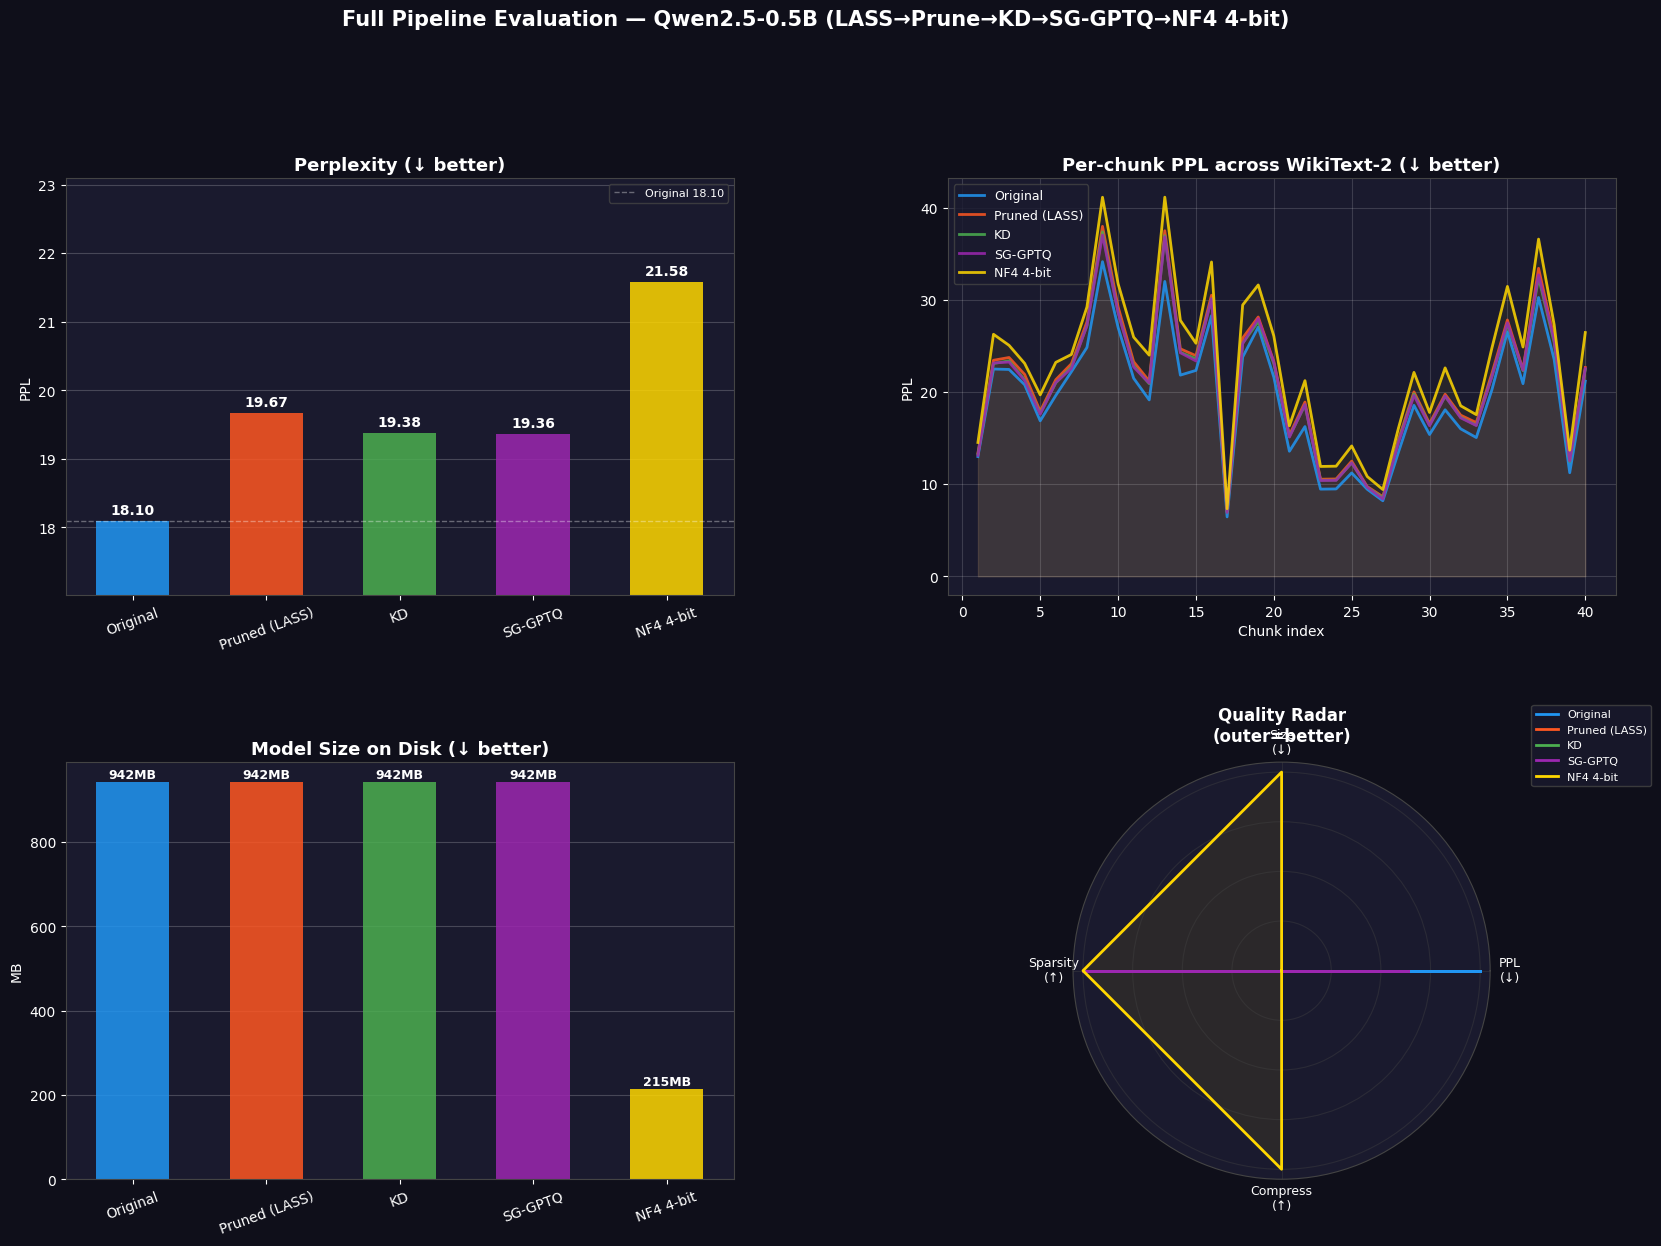

Saved: /kaggle/working/eval_plots/fig1_overview.png


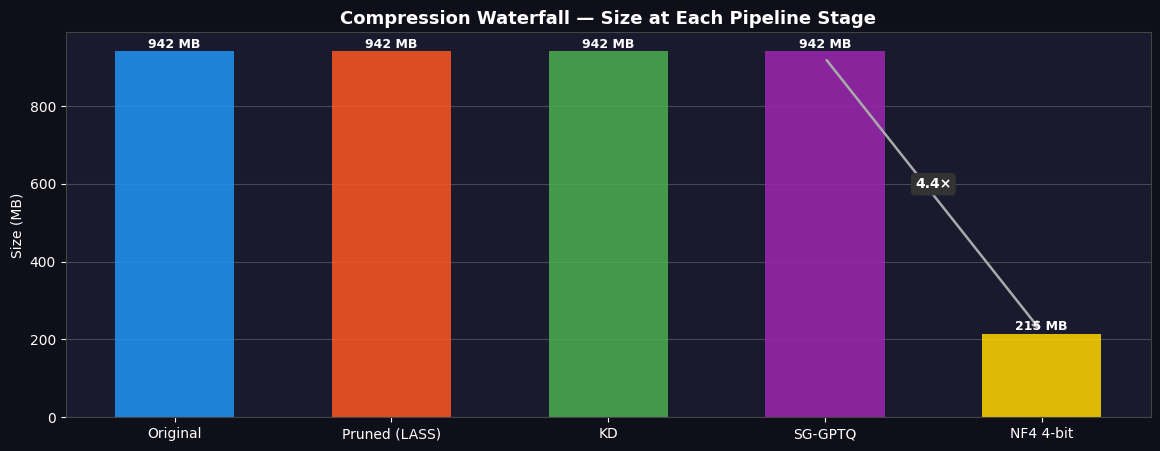

Saved: /kaggle/working/eval_plots/fig2_compression_waterfall.png


/tmp/ipykernel_57/1525634742.py:434: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig3.savefig(path3, dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
/tmp/ipykernel_57/1525634742.py:434: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig3.savefig(path3, dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


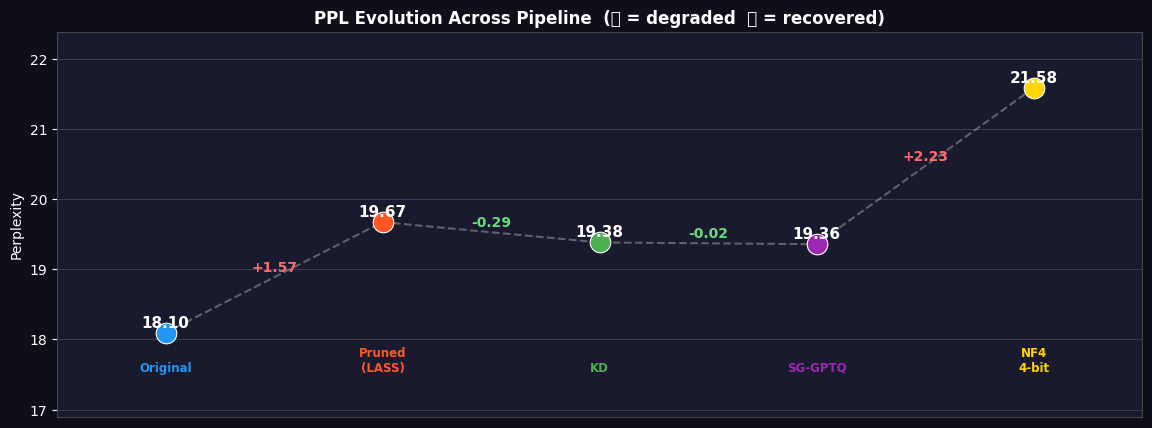

Saved: /kaggle/working/eval_plots/fig3_ppl_pipeline.png


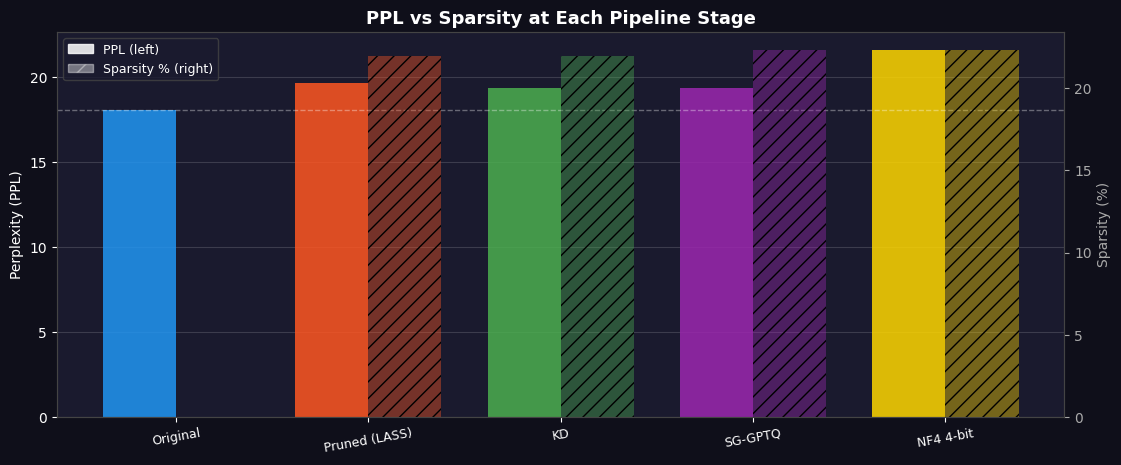

Saved: /kaggle/working/eval_plots/fig4_ppl_vs_sparsity.png


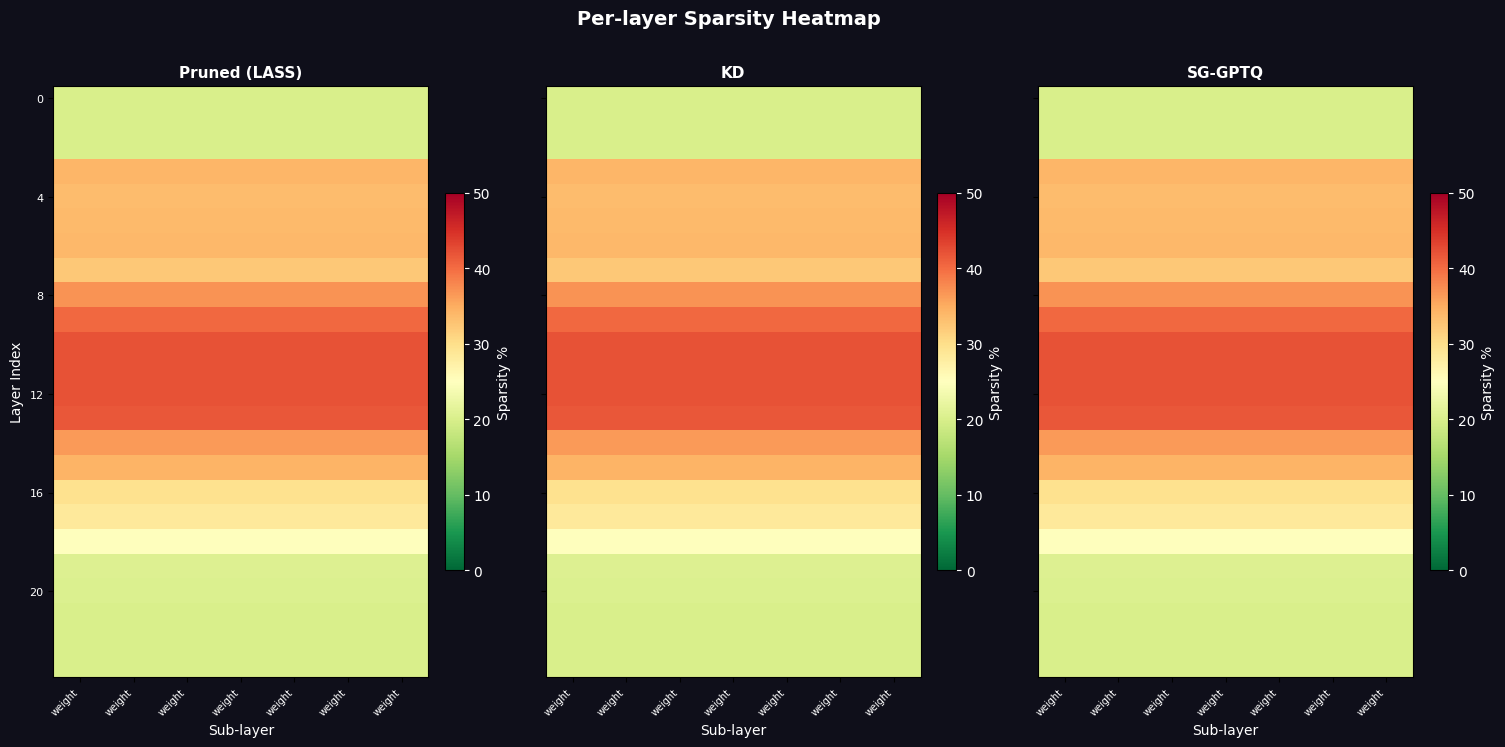

Saved: /kaggle/working/eval_plots/fig5_layer_heatmap.png
Generation results: /kaggle/working/eval_plots/generation_results.txt


 FINAL RESULTS
Model                       PPL      ΔPPL   Sparsity      Size   Compression
---------------------------------------------------------------------------
Original                  18.10         —      0.00%     942MB          1.0×
Pruned (LASS)             19.67     +1.57     21.96%     942MB          1.0×
KD                        19.38     +1.29     21.96%     942MB          1.0×
SG-GPTQ                   19.36     +1.26     22.31%     942MB          1.0×
NF4 4-bit                 21.58     +3.49     22.31%     215MB          4.4×

All plots → /kaggle/working/eval_plots
DONE ✓


11820

In [11]:


import os, gc, sys, math, json, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig,
    LogitsProcessor, LogitsProcessorList
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


BASE_MODEL   = "Qwen/Qwen2.5-0.5B-Instruct"
PRUNED_MODEL = "/kaggle/working/pruned_lass"
KD_MODEL     = "/kaggle/working/final_sparse_kd"
SGPTQ_MODEL  = "/kaggle/working/sg_gptq_model"
PLOT_DIR     = "/kaggle/working/eval_plots"
os.makedirs(PLOT_DIR, exist_ok=True)


class ClampLogits(LogitsProcessor):
    def __call__(self, input_ids, scores):
        return torch.clamp(scores, -20, 20)

processors = LogitsProcessorList([ClampLogits()])



def compute_ppl_chunked_hf(model, tokenizer, dev, seqlen=512, n_chunks=40):
    model.eval()
    data      = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
    enc       = tokenizer(full_text, return_tensors="pt").input_ids
    nlls, total_chunks = [], min(n_chunks, enc.shape[1] // seqlen)
    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(dev)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        nlls.append(loss * (seqlen - 1))
    return torch.exp(torch.stack(nlls).sum() / (total_chunks * (seqlen - 1))).item()


def compute_ppl_per_chunk_hf(model, tokenizer, dev, seqlen=512, n_chunks=40):
    model.eval()
    data      = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    full_text = "\n\n".join(data["text"])
    enc       = tokenizer(full_text, return_tensors="pt").input_ids
    ppls, total_chunks = [], min(n_chunks, enc.shape[1] // seqlen)
    for i in range(total_chunks):
        batch = enc[:, i * seqlen:(i + 1) * seqlen].to(dev)
        with torch.no_grad():
            loss = model(batch, labels=batch).loss.float()
        ppls.append(torch.exp(loss).item())
    return ppls


def compute_sparsity(model):
    total, zeros = 0, 0
    for n, p in model.named_parameters():
        if "weight" in n and p.dim() >= 2:
            total += p.numel()
            zeros += (p == 0).sum().item()
    return 100.0 * zeros / total if total > 0 else 0.0


def model_size_mb(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / (1024 * 1024)
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            if f.endswith(".safetensors") or f.endswith(".bin"):
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024 * 1024)


def model_size_mb_4bit(model):
    # bitsandbytes 4-bit can't be saved, so estimate from param memory
    total_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
    # NF4 stores 2 values per byte → divide by 2
    return (total_bytes / 2) / (1024 * 1024)


def generate_hf(model, tokenizer, prompt, dev, max_new=80):
    model.eval()
    enc = tokenizer(prompt, return_tensors="pt").to(dev)
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=max_new,
            do_sample=True, temperature=0.7, top_p=0.9,
            repetition_penalty=1.2, no_repeat_ngram_size=3,
            logits_processor=processors,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][enc["input_ids"].shape[-1]:],
                            skip_special_tokens=True)


def compute_per_layer_sparsity(model):
    records = []
    for name, param in model.named_parameters():
        if "weight" in name and param.dim() >= 2 and "layers." in name:
            sp    = 100.0 * (param == 0).sum().item() / param.numel()
            parts = name.split(".")
            try:
                idx   = parts.index("layers")
                layer = int(parts[idx + 1])
                sub   = ".".join(parts[idx + 2:])
                records.append((layer, sub, sp))
            except (ValueError, IndexError):
                continue
    return records



print("\n" + "="*65)
print("PHASE 1: HF MODELS")
print("="*65)

hf_cfgs = [
    ("Original",      BASE_MODEL,   "#2196F3"),
    ("Pruned (LASS)", PRUNED_MODEL, "#FF5722"),
    ("KD",            KD_MODEL,     "#4CAF50"),
    ("SG-GPTQ",       SGPTQ_MODEL,  "#9C27B0"),
]

results      = {}
layer_sparse = {}

for label, path, color in hf_cfgs:
    print(f"\n── {label} ──")
    tok = AutoTokenizer.from_pretrained(path)
    tok.pad_token = tok.eos_token
    mdl = AutoModelForCausalLM.from_pretrained(
        path,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto"
    )
    mdl.eval()
    dev = next(mdl.parameters()).device

    sp         = compute_sparsity(mdl)
    chunk_ppls = compute_ppl_per_chunk_hf(mdl, tok, dev)
    ppl        = math.exp(np.mean([math.log(p) for p in chunk_ppls]))
    sz         = model_size_mb(path) if path != BASE_MODEL else \
                 sum(p.numel() * 2 for p in mdl.parameters()) / 1024**2

    layer_sparse[label] = compute_per_layer_sparsity(mdl)
    results[label] = {
        "ppl":        round(ppl, 3),
        "sparsity":   round(sp, 2),
        "size_mb":    round(sz, 1),
        "chunk_ppls": chunk_ppls,
        "color":      color,
        "model_obj":  mdl,
        "tok":        tok,
        "dev":        dev,
    }
    print(f"  PPL={ppl:.2f}  Sparsity={sp:.2f}%  Size={sz:.0f}MB")



print("\n" + "="*65)
print("PHASE 2: NF4 4-BIT QUANTIZED MODEL")
print("="*65)

tok_4bit = AutoTokenizer.from_pretrained(SGPTQ_MODEL)
tok_4bit.pad_token = tok_4bit.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
mdl_4bit = AutoModelForCausalLM.from_pretrained(
    SGPTQ_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
mdl_4bit.eval()
dev_4bit = next(mdl_4bit.parameters()).device
print("4-bit model loaded ✓")

chunk_ppls_4bit = compute_ppl_per_chunk_hf(mdl_4bit, tok_4bit, dev_4bit)
ppl_4bit        = math.exp(np.mean([math.log(p) for p in chunk_ppls_4bit]))
sz_4bit         = model_size_mb_4bit(mdl_4bit)
sp_4bit         = results["SG-GPTQ"]["sparsity"]   # same weights, quantized format

print(f"  PPL={ppl_4bit:.2f}  Size≈{sz_4bit:.0f}MB  (NF4 proxy for GGUF Q4_K_M)")

results["NF4 4-bit"] = {
    "ppl":        round(ppl_4bit, 3),
    "sparsity":   sp_4bit,
    "size_mb":    round(sz_4bit, 1),
    "chunk_ppls": chunk_ppls_4bit,
    "color":      "#FFD700",
    "model_obj":  mdl_4bit,
    "tok":        tok_4bit,
    "dev":        dev_4bit,
}



print("\n" + "="*65)
print("PHASE 3: GENERATION COMPARISON")
print("="*65)

prompts = [
    "What is artificial intelligence?",
    "What is the capital of France?",
    "Who developed the theory of relativity?",
    "Explain machine learning in simple words.",
    "Explain pruning and quantization.",
    "Write a short paragraph about climate change.",
    "What is photosynthesis?",
    "What is Newton's second law?",
    "What is 2 + 2?",
    "Write a short motivational paragraph."
]

gen_results = {lbl: [] for lbl in results}

for i, prompt in enumerate(prompts, 1):
    print(f"\nQ{i}: {prompt}")
    for lbl, cfg in results.items():
        ans = generate_hf(cfg["model_obj"], cfg["tok"], prompt, cfg["dev"])
        gen_results[lbl].append(ans)
        print(f"  [{lbl}]: {ans[:100]}{'...' if len(ans)>100 else ''}")



labels   = list(results.keys())
orig_ppl = results["Original"]["ppl"]

print("\n\n" + "="*80)
print("       FULL PIPELINE RESULTS TABLE")
print("="*80)
print(f"{'Model':<22} {'PPL':>8} {'ΔPPL':>9} {'Sparsity':>10} {'Size(MB)':>10} {'Compress':>10}")
print("-"*72)
for lbl in labels:
    r    = results[lbl]
    ppl_ = r["ppl"]
    ps   = f"{ppl_:>8.2f}"
    dp   = f"+{ppl_-orig_ppl:.2f}" if lbl != "Original" else "    —"
    comp = f"{results['Original']['size_mb']/max(r['size_mb'],1):.1f}×" \
           if lbl != "Original" else "   1.0×"
    print(f"{lbl:<22} {ps} {dp:>9} {r['sparsity']:>9.2f}% "
          f"{r['size_mb']:>9.0f}  {comp:>10}")
print("="*80)


print("\nGenerating plots...")

COLORS = [results[l]["color"] for l in labels]
ppls   = [results[l]["ppl"]     for l in labels]
sizes  = [results[l]["size_mb"] for l in labels]


fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor("#0f0f1a")
gs  = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.32)

axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]
for ax in axes:
    ax.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    ax.title.set_color("white")
    for sp in ax.spines.values():
        sp.set_edgecolor("#444")

ax_ppl, ax_curve, ax_size, _ = axes

# 1A — PPL bar
bars = ax_ppl.bar(labels, ppls, color=COLORS, alpha=0.85, width=0.55, zorder=2)
ax_ppl.axhline(orig_ppl, color="white", ls="--", lw=1, alpha=0.35,
               label=f"Original {orig_ppl:.2f}")
ax_ppl.set_title("Perplexity (↓ better)", fontsize=13, fontweight="bold")
ax_ppl.set_ylabel("PPL", color="white")
ax_ppl.set_ylim(min(ppls)*0.94, max(ppls)*1.07)
ax_ppl.tick_params(axis="x", rotation=20)
ax_ppl.yaxis.label.set_color("white")
for bar, val in zip(bars, ppls):
    ax_ppl.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{val:.2f}", ha="center", color="white", fontsize=10, fontweight="bold")
ax_ppl.legend(fontsize=8, labelcolor="white", facecolor="#1a1a2e", edgecolor="#444")
ax_ppl.grid(axis="y", alpha=0.2, color="white")

# 1B — per-chunk PPL curves
for lbl in labels:
    cppls = results[lbl]["chunk_ppls"]
    if not cppls:
        continue
    xs = list(range(1, len(cppls)+1))
    ax_curve.plot(xs, cppls, color=results[lbl]["color"], lw=2, alpha=0.85, label=lbl)
    ax_curve.fill_between(xs, cppls, alpha=0.06, color=results[lbl]["color"])
ax_curve.set_title("Per-chunk PPL across WikiText-2 (↓ better)", fontsize=13, fontweight="bold")
ax_curve.set_xlabel("Chunk index", color="white")
ax_curve.set_ylabel("PPL", color="white")
ax_curve.xaxis.label.set_color("white")
ax_curve.yaxis.label.set_color("white")
ax_curve.legend(fontsize=9, labelcolor="white", facecolor="#1a1a2e", edgecolor="#444")
ax_curve.grid(alpha=0.15, color="white")

# 1C — size bar
bars_size = ax_size.bar(labels, sizes, color=COLORS, alpha=0.85, width=0.55, zorder=2)
ax_size.set_title("Model Size on Disk (↓ better)", fontsize=13, fontweight="bold")
ax_size.set_ylabel("MB", color="white")
ax_size.tick_params(axis="x", rotation=20)
ax_size.yaxis.label.set_color("white")
for bar, val in zip(bars_size, sizes):
    ax_size.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                 f"{val:.0f}MB", ha="center", color="white", fontsize=9, fontweight="bold")
ax_size.grid(axis="y", alpha=0.2, color="white")

# 1D — Radar
axes[3].remove()
ax_radar = fig.add_subplot(gs[1, 1], polar=True)
ax_radar.set_facecolor("#1a1a2e")
ax_radar.spines["polar"].set_color("#444")

def norm_inv(vals):
    arr = np.array(vals, dtype=float)
    mn, mx = arr.min(), arr.max()
    return 1 - (arr - mn) / (mx - mn + 1e-9)

def norm_fwd(vals):
    arr = np.array(vals, dtype=float)
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)

radar_labels_list = ["PPL\n(↓)", "Size\n(↓)", "Sparsity\n(↑)", "Compress\n(↑)"]
raw_ppl  = [results[l]["ppl"]      for l in labels]
raw_size = [results[l]["size_mb"]  for l in labels]
raw_sp   = [results[l]["sparsity"] for l in labels]
raw_comp = [results["Original"]["size_mb"] / max(results[l]["size_mb"], 1) for l in labels]
normed   = np.stack([
    norm_inv(raw_ppl), norm_inv(raw_size),
    norm_fwd(raw_sp),  norm_fwd(raw_comp)
], axis=1)

N      = 4
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
for i, (lbl, color) in enumerate(zip(labels, COLORS)):
    vals = normed[i].tolist() + [normed[i][0]]
    ax_radar.plot(angles, vals, color=color, lw=2, label=lbl)
    ax_radar.fill(angles, vals, color=color, alpha=0.08)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(radar_labels_list, color="white", fontsize=9)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(["", "", "", ""], fontsize=7)
ax_radar.set_title("Quality Radar\n(outer=better)", fontsize=12,
                   fontweight="bold", color="white", pad=15)
ax_radar.legend(fontsize=8, labelcolor="white", facecolor="#1a1a2e",
                edgecolor="#444", loc="upper right", bbox_to_anchor=(1.4, 1.15))
ax_radar.grid(color="#444", alpha=0.4)

fig.suptitle("Full Pipeline Evaluation — Qwen2.5-0.5B (LASS→Prune→KD→SG-GPTQ→NF4 4-bit)",
             fontsize=15, fontweight="bold", color="white", y=1.01)
path1 = os.path.join(PLOT_DIR, "fig1_overview.png")
fig.savefig(path1, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {path1}")


fig2, ax2 = plt.subplots(figsize=(14, 5))
fig2.patch.set_facecolor("#0f0f1a")
ax2.set_facecolor("#1a1a2e")

bars2 = ax2.bar(labels, sizes, color=COLORS, alpha=0.85, width=0.55, zorder=2)
for i in range(1, len(sizes)):
    prev, curr = sizes[i-1], sizes[i]
    if curr < prev - 5:
        ratio = prev / curr
        mid_x = i - 0.5
        ax2.annotate("", xy=(i, curr*1.02), xytext=(i-1, prev*0.98),
                     arrowprops=dict(arrowstyle="->", color="#aaa", lw=1.8))
        ax2.text(mid_x, (prev+curr)/2 + 10, f"{ratio:.1f}×",
                 ha="center", color="white", fontsize=10, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="#333", ec="none"))
for bar, val in zip(bars2, sizes):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
             f"{val:.0f} MB", ha="center", color="white", fontsize=9, fontweight="bold")
ax2.set_title("Compression Waterfall — Size at Each Pipeline Stage",
              fontsize=13, fontweight="bold", color="white")
ax2.set_ylabel("Size (MB)", color="white")
ax2.tick_params(colors="white")
ax2.yaxis.label.set_color("white")
for sp in ax2.spines.values(): sp.set_edgecolor("#444")
ax2.grid(axis="y", alpha=0.2, color="white")
path2 = os.path.join(PLOT_DIR, "fig2_compression_waterfall.png")
fig2.savefig(path2, dpi=150, bbox_inches="tight", facecolor=fig2.get_facecolor())
plt.show()
print(f"Saved: {path2}")



fig3, ax3 = plt.subplots(figsize=(14, 5))
fig3.patch.set_facecolor("#0f0f1a")
ax3.set_facecolor("#1a1a2e")

ax3.plot(range(len(labels)), ppls, color="white", lw=1.5, ls="--", alpha=0.3, zorder=1)
for i, (lbl, ppl_, col) in enumerate(zip(labels, ppls, COLORS)):
    ax3.scatter(i, ppl_, color=col, s=220, zorder=3, edgecolors="white", linewidths=0.8)
    ax3.text(i, ppl_ + 0.08, f"{ppl_:.2f}",
             ha="center", color="white", fontsize=11, fontweight="bold")
    ax3.text(i, min(ppls) - 0.55, lbl.replace(" ", "\n"),
             ha="center", color=col, fontsize=8.5, fontweight="bold")
for i in range(1, len(labels)):
    delta = ppls[i] - ppls[i-1]
    mid_x = i - 0.5
    mid_y = (ppls[i] + ppls[i-1]) / 2
    sign  = "+" if delta >= 0 else ""
    col   = "#ff6b6b" if delta > 0 else "#69db7c"
    ax3.text(mid_x, mid_y + 0.08, f"{sign}{delta:.2f}",
             ha="center", color=col, fontsize=10, fontweight="bold")
ax3.set_xlim(-0.5, len(labels) - 0.5)
ax3.set_ylim(min(ppls) - 1.2, max(ppls) + 0.8)
ax3.set_xticks([])
ax3.set_ylabel("Perplexity", color="white")
ax3.yaxis.label.set_color("white")
ax3.tick_params(colors="white")
for sp in ax3.spines.values(): sp.set_edgecolor("#444")
ax3.set_title("PPL Evolution Across Pipeline  (🔴 = degraded  🟢 = recovered)",
              fontsize=12, fontweight="bold", color="white")
ax3.grid(axis="y", alpha=0.15, color="white")
path3 = os.path.join(PLOT_DIR, "fig3_ppl_pipeline.png")
fig3.savefig(path3, dpi=150, bbox_inches="tight", facecolor=fig3.get_facecolor())
plt.show()
print(f"Saved: {path3}")


fig4, ax4a = plt.subplots(figsize=(13, 5))
fig4.patch.set_facecolor("#0f0f1a")
ax4a.set_facecolor("#1a1a2e")
ax4b = ax4a.twinx()

x = np.arange(len(labels))
w = 0.38
ax4a.bar(x - w/2, ppls, w, color=COLORS, alpha=0.85, label="PPL", zorder=2)
ax4b.bar(x + w/2, [results[l]["sparsity"] for l in labels],
         w, color=COLORS, alpha=0.4, hatch="//", label="Sparsity %", zorder=2)
ax4a.axhline(orig_ppl, color="white", ls="--", lw=1, alpha=0.35)
ax4a.set_xticks(x)
ax4a.set_xticklabels(labels, color="white", fontsize=9, rotation=10)
ax4a.set_ylabel("Perplexity (PPL)", color="white")
ax4a.yaxis.label.set_color("white")
ax4a.tick_params(colors="white")
ax4b.set_ylabel("Sparsity (%)", color="#aaa")
ax4b.yaxis.label.set_color("#aaa")
ax4b.tick_params(colors="#aaa")
for sp in ax4a.spines.values(): sp.set_edgecolor("#444")
for sp in ax4b.spines.values(): sp.set_edgecolor("#444")
p1 = mpatches.Patch(color="white", alpha=0.85, label="PPL (left)")
p2 = mpatches.Patch(color="white", alpha=0.4, hatch="//", label="Sparsity % (right)")
ax4a.legend(handles=[p1, p2], fontsize=9, labelcolor="white",
            facecolor="#1a1a2e", edgecolor="#444")
ax4a.set_title("PPL vs Sparsity at Each Pipeline Stage",
               fontsize=13, fontweight="bold", color="white")
ax4a.grid(axis="y", alpha=0.15, color="white")
path4 = os.path.join(PLOT_DIR, "fig4_ppl_vs_sparsity.png")
fig4.savefig(path4, dpi=150, bbox_inches="tight", facecolor=fig4.get_facecolor())
plt.show()
print(f"Saved: {path4}")



sparse_labels = [l for l in labels if results[l]["sparsity"] > 0
                 and l in layer_sparse and layer_sparse[l]]
if sparse_labels:
    n_layers_max = max(r[0] for l in sparse_labels for r in layer_sparse[l]) + 1
    sl_global    = sorted({r[1] for l in sparse_labels for r in layer_sparse[l]})[:8]
    sl_idx       = {s: i for i, s in enumerate(sl_global)}

    fig5, axes5 = plt.subplots(
        1, len(sparse_labels),
        figsize=(6*len(sparse_labels), max(7, n_layers_max*0.32)),
        sharey=True
    )
    fig5.patch.set_facecolor("#0f0f1a")
    if len(sparse_labels) == 1:
        axes5 = [axes5]

    for ax5, lbl in zip(axes5, sparse_labels):
        ax5.set_facecolor("#1a1a2e")
        matrix = np.full((n_layers_max, len(sl_global)), np.nan)
        for (li, sn, sp) in layer_sparse[lbl]:
            if sn in sl_idx:
                matrix[li, sl_idx[sn]] = sp
        im = ax5.imshow(matrix, aspect="auto", cmap="RdYlGn_r",
                        vmin=0, vmax=50, interpolation="nearest")
        ax5.set_title(f"{lbl}", color="white", fontsize=11, fontweight="bold")
        ax5.set_xlabel("Sub-layer", color="white")
        if ax5 is axes5[0]:
            ax5.set_ylabel("Layer Index", color="white")
        ax5.set_xticks(range(len(sl_global)))
        ax5.set_xticklabels([s.split(".")[-1] for s in sl_global],
                             rotation=45, ha="right", color="white", fontsize=7)
        ax5.set_yticks(range(0, n_layers_max, 4))
        ax5.set_yticklabels(range(0, n_layers_max, 4), color="white", fontsize=8)
        cb = fig5.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
        cb.ax.yaxis.set_tick_params(color="white")
        cb.ax.set_ylabel("Sparsity %", color="white")
        plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

    fig5.suptitle("Per-layer Sparsity Heatmap",
                  fontsize=14, fontweight="bold", color="white")
    path5 = os.path.join(PLOT_DIR, "fig5_layer_heatmap.png")
    fig5.savefig(path5, dpi=150, bbox_inches="tight", facecolor=fig5.get_facecolor())
    plt.show()
    print(f"Saved: {path5}")



gen_path = os.path.join(PLOT_DIR, "generation_results.txt")
with open(gen_path, "w") as f:
    f.write("GENERATION COMPARISON\n" + "="*70 + "\n\n")
    for i, prompt in enumerate(prompts, 1):
        f.write(f"Q{i}: {prompt}\n")
        for lbl in gen_results:
            ans = gen_results[lbl][i-1] if i-1 < len(gen_results[lbl]) else ""
            f.write(f"\n  [{lbl}]:\n  {ans}\n")
        f.write("\n" + "-"*70 + "\n\n")
print(f"Generation results: {gen_path}")

summary = {
    "models": {
        lbl: {
            "ppl":         results[lbl]["ppl"],
            "sparsity":    results[lbl]["sparsity"],
            "size_mb":     results[lbl]["size_mb"],
            "delta_ppl":   round(results[lbl]["ppl"] - orig_ppl, 3),
            "compression": round(results["Original"]["size_mb"] /
                                 max(results[lbl]["size_mb"], 1), 2),
        }
        for lbl in labels
    }
}
with open(os.path.join(PLOT_DIR, "eval_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("\n\n" + "="*80)
print(" FINAL RESULTS")
print("="*80)
print(f"{'Model':<22} {'PPL':>8} {'ΔPPL':>9} {'Sparsity':>10} {'Size':>9} {'Compression':>13}")
print("-"*75)
for lbl in labels:
    r    = results[lbl]
    ps   = f"{r['ppl']:.2f}"
    dp   = f"+{r['ppl']-orig_ppl:.2f}" if lbl != "Original" else "—"
    comp = f"{results['Original']['size_mb']/max(r['size_mb'],1):.1f}×" \
           if lbl != "Original" else "1.0×"
    print(f"{lbl:<22} {ps:>8} {dp:>9} {r['sparsity']:>9.2f}% "
          f"{r['size_mb']:>7.0f}MB {comp:>13}")
print("="*80)
print(f"\nAll plots → {PLOT_DIR}")
print("DONE ✓")

# cleanup
for lbl in list(results.keys()):
    if "model_obj" in results[lbl]:
        del results[lbl]["model_obj"]
torch.cuda.empty_cache()
gc.collect()